# Digital Waveguide Synthesis of a String

This notebook is an exploration into the digital waveguide synthesis method for simulating the sound of a string.

Randall Ali

In [1]:
import numpy as np 
import scipy as sp
from scipy import signal
import sounddevice as sd
import soundfile as sf
from matplotlib import pyplot as plt
from  matplotlib import patches
from matplotlib.ticker import FormatStrFormatter
from ipywidgets import * # interactive plots
import IPython
from IPython.display import Audio, Image, Video
from matplotlib.animation import FuncAnimation
import mpl_toolkits.axes_grid1
import matplotlib.widgets
%matplotlib ipympl



### New outline

1. A discussion about the physics of a string - arriving to the wave equation and its solution
2. An input function - a plucked string (can design different inputs)
3. An understanding of the solution as a sum of left-going and right-going waves (animation here).
4. What's happening in space and time (moving the dot on the string)
5. Full animation.
6. Another interactive plot to move around pluck/pickup position
7. Digital waveguides - what's a delay line?
8. Termination at the rigid ends
9. Grouping the entire system.
10. Karplus Strong model - filtering - a look at spectrograms...

### Digital waveguide synthesis

I need to write a bit more on all of this explaining the details. 
Here are the links of interest:

https://en.wikipedia.org/wiki/Digital_waveguide_synthesis

https://www.ee.columbia.edu/~ronw/dsp/

https://ccrma.stanford.edu/~jos/pasp/Digital_Waveguide_Models.html

Outline:
1. Do function for DWS
2. Plot time domain and spectrogram
3. Make an interactive plot varying parameters


In [2]:
# functions

# DWS

def dws (sound_len, freq, PL, PU, decay, fs):

    # Function to do the digital wave synthesis of a simple string
    
    # sound_len = length of the output sound (s)
    # freq - desired frequency of sound (Hz)
    # PL - normalized position of the input excitation (a number from 0 to 1)
    # PU - normalized position of the pickup position  (a number from 0 to 1)
    # decay - coefficient between 0 and 1 which determines how damped the string is. Higher values = less damped 
    # fs - sampling frequency (Hz)
    
    N = sound_len*fs # total number of samples
     
    L = int(np.round(fs/(freq*2)))  # approximate length of string needed for the desired freq
    pluck_pos = int(np.round(PL*L)) # position on string where it is to be plucked
    pick_pos = int(np.round(PU*L))  # position on string where it is to be picked up
    
    
    # defining the input function - a triangle wave input (this should probably be made into a function)
    xx = np.arange(0,L,1)
    pluck_input = np.zeros(len(xx))
    pluck_input[0:pluck_pos+1] = (0.5/pluck_pos)*xx[0:pluck_pos+1] # first ramp of triangle wave
    pluck_input[pluck_pos+1:L] = .5/(pluck_pos-(L-1))*xx[pluck_pos+1:L] - .5*(L-1)/(pluck_pos-(L-1)) # descending ramp

    # initial left an right going waves
    yl = pluck_input.copy()
    yr = pluck_input.copy()
    
    y_out = np.zeros(N)

    for j in np.arange(0,N,1): # generating each sample of the temporal sound

        # output is the sum of the left going and right going wave
        y_out[j] = yl[pick_pos] + yr[pick_pos]

        # Now we need to update the motion of the left going and right going waves
        # The damping/losses is introduced at the ends of the string

        yr[1:L] = yr[0:L-1] # shifting the motion to the right
        yl[0:L-1] = yl[1:L] # shifting the motion  to the left
    
        yr[0] = -decay*yl[0] # losses
        yl[-1] = -decay*yr[-1] # losses

    return y_out, pluck_input, xx, pluck_pos, pick_pos 

    


### Travelling waves to the right and to the left


Move the slider to see how the string is synthesized as the sum of left and right going waves at the pickup position:


interactive(children=(IntSlider(value=0, description='n', max=500), FloatSlider(value=0.85, description='PU', …

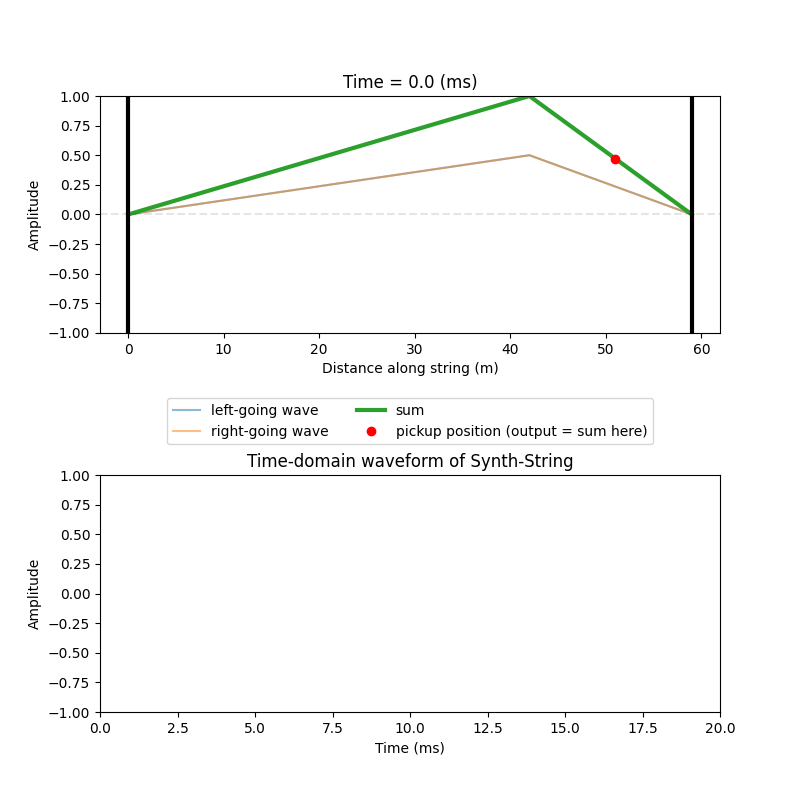

In [3]:
### Another animation

# TO DO - MAKE ANIMATION NOT FLICKER - RENDERING OF SOUND.


##### Animation to Synth some strings #######

fs = 24000 # sampling freq (Hz)
T = 1  # length of sound (s)
freq = 200 # string fundamental freq (Hz)
PL = 0.7
PU = 0.85
decay = 0.99

tt = np.arange(0,T,1/fs)   # time range of signal
[y_out, pluck_input, xx, pluck_pos, pick_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!
L = len(xx) # number of spatial samples for string

# We're going to repeat a few things from the function here just so 
# that we understand how the waveform is being generated. After that we'll analyze it a bit more.

# This is a pre-computation for left/right strings
yl = np.zeros([L,T*fs])
yr = np.zeros([L,T*fs])

yl[:,0] = pluck_input.copy()
yr[:,0] = pluck_input.copy()

for j in np.arange(0,T*fs-1,1): # generating each sample of the temporal sound
    

    yr[1:L,j+1] = yr[0:L-1,j] # shifting the motion to the right
    yl[0:L-1,j+1] = yl[1:L,j] # shifting the motion  to the left
    
    yr[0,j+1] = -decay*yl[0,j+1] # losses
    yl[-1,j+1] = -decay*yr[-1,j+1] # losses
    


# Setup the plot environments

fig, axes = plt.subplots(2,1,figsize=(8, 8)) 
fig.subplots_adjust(hspace=0.6)
line_left, = axes[0].plot(xx,pluck_input,label='left-going wave',alpha=0.5)
line_right, = axes[0].plot(xx,pluck_input,label='right-going wave', alpha=0.5)
line_sum, = axes[0].plot(xx,pluck_input+pluck_input,label='sum',linewidth=3)
line_sum_pt, = axes[0].plot(pick_pos,pluck_input[pick_pos]+pluck_input[pick_pos],'ro', label='pickup position (output = sum here)')
axes[0].axvline(x=xx[0],color='k',linestyle='-',linewidth=3)
axes[0].axvline(x=xx[-1],color='k',linestyle='-',linewidth=3)
axes[0].axhline(y=0,color='k',linestyle='--',alpha=0.1)

# axes[0].axvline(x=pick_pos,color='g',linestyle='--',label='pickup position (output = sum here)')
# axes[0].axvline(x=pluck_pos,color='k',linestyle='--',label='pluck position (input here)')
axes[0].set_xlabel('Distance along string (m)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim([-1, 1])
axes[0].legend(loc='lower center',ncol=2,bbox_to_anchor=[0.5, -0.5])



axes[1].plot([])
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Time-domain waveform of Synth-String')
axes[1].set_xlim([0, 20])
axes[1].set_ylim(-1, 1)
line2, = axes[1].plot([],[],'r-',linewidth=1, markersize=1)



N_frames = int(np.round(0.1*fs)) 

def update(n = 0, PU=0.85):

    # Change pickup position

    [y_out, pluck_input, xx, pluck_pos, pick_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!
        

    # Plot
    line_left.set_data(xx,yl[:,n])
    line_right.set_data(xx,yr[:,n])
    axes[0].set_title('Time = '+str(np.round(n/fs *1000, decimals=2))+ ' (ms)')
    line_sum.set_data(xx,yl[:,n] + yr[:,n])
    line_sum_pt.set_data([pick_pos], [yl[pick_pos,n] + yr[pick_pos,n]])
    line2.set_data(tt[0:n+1]*1000, y_out[0:n+1])

    # print("Listen to the synth string signal:")
    IPython.display.display(Audio(y_out.T, rate=fs,normalize=True))
    
print('Move the slider to see how the string is synthesized as the sum of left and right going waves at the pickup position:')
interact(update, n = (0,500,1), PU=(0.1,0.9,0.05));

# def animate_string(n): 

#     line_left.set_data(xx,yl[:,n])
#     line_right.set_data(xx,yr[:,n])
#     line_sum.set_data(xx,yl[:,n] + yr[:,n])
#     line2.set_data(tt[0:n+1], y_out[0:n+1])
    
#     return line_left, line_right, line_sum, line2

# anim = FuncAnimation(fig, animate_string, frames=N_frames, interval=40, blit=False) # this calls the function to do the animation
# plt.show()
# # plt.close(fig)


# # Option 1: GIF (no ffmpeg)
# #anim.save("string_animation.gif", writer="pillow", fps=30)


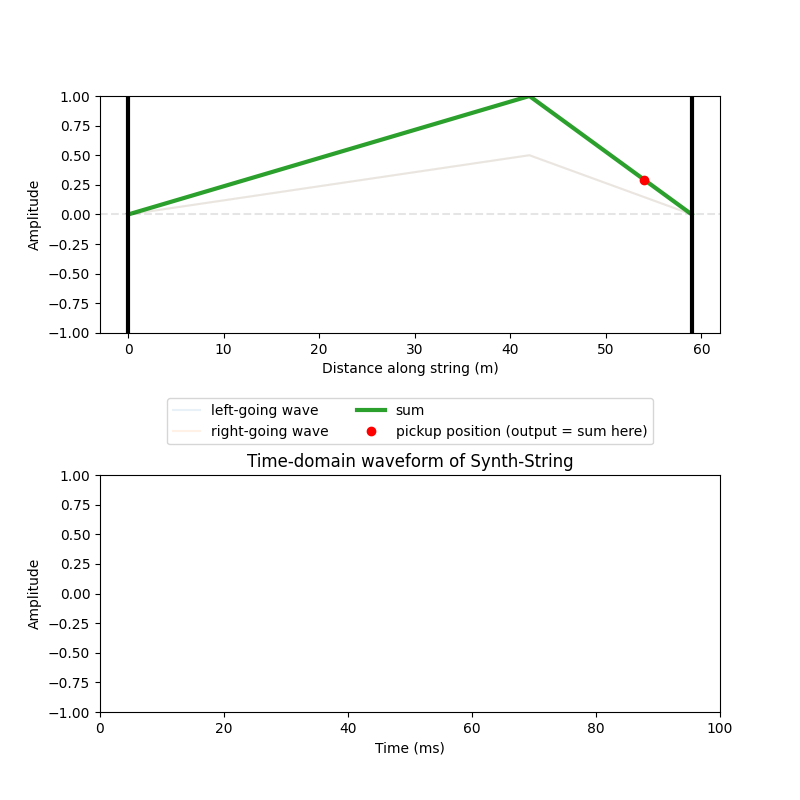

In [5]:
### Another animation

# TO DO - MAKE ANIMATION NOT FLICKER - RENDERING OF SOUND.


##### Animation to Synth some strings #######

fs = 24000 # sampling freq (Hz)
T = 1  # length of sound (s)
freq = 200 # string fundamental freq (Hz)
PL = 0.7
PU = 0.9
decay = 0.99

tt = np.arange(0,T,1/fs)   # time range of signal
[y_out, pluck_input, xx, pluck_pos, pick_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!
L = len(xx) # number of spatial samples for string

# We're going to repeat a few things from the function here just so 
# that we understand how the waveform is being generated. After that we'll analyze it a bit more.

# This is a pre-computation for left/right strings
yl = np.zeros([L,T*fs])
yr = np.zeros([L,T*fs])

yl[:,0] = pluck_input.copy()
yr[:,0] = pluck_input.copy()

for j in np.arange(0,T*fs-1,1): # generating each sample of the temporal sound
    

    yr[1:L,j+1] = yr[0:L-1,j] # shifting the motion to the right
    yl[0:L-1,j+1] = yl[1:L,j] # shifting the motion  to the left
    
    yr[0,j+1] = -decay*yl[0,j+1] # losses
    yl[-1,j+1] = -decay*yr[-1,j+1] # losses
    


# Setup the plot environments

fig_anim, axes = plt.subplots(2,1,figsize=(8, 8)) 
fig_anim.subplots_adjust(hspace=0.6)
line_left, = axes[0].plot(xx,pluck_input,label='left-going wave',alpha=0.1)
line_right, = axes[0].plot(xx,pluck_input,label='right-going wave',alpha=0.1)
line_sum, = axes[0].plot(xx,pluck_input+pluck_input,label='sum',linewidth=3)
line_sum_pt, = axes[0].plot(pick_pos,pluck_input[pick_pos]+pluck_input[pick_pos],'ro', label='pickup position (output = sum here)')
axes[0].axvline(x=xx[0],color='k',linestyle='-',linewidth=3)
axes[0].axvline(x=xx[-1],color='k',linestyle='-',linewidth=3)
axes[0].axhline(y=0,color='k',linestyle='--',alpha=0.1)

# axes[0].axvline(x=pick_pos,color='g',linestyle='--',label='pickup position (output = sum here)')
# axes[0].axvline(x=pluck_pos,color='k',linestyle='--',label='pluck position (input here)')
axes[0].set_xlabel('Distance along string (m)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim([-1, 1])
axes[0].legend(loc='lower center',ncol=2,bbox_to_anchor=[0.5, -0.5])



axes[1].plot([])
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Time-domain waveform of Synth-String')
axes[1].set_xlim([0, 100])
axes[1].set_ylim(-1, 1)
line2, = axes[1].plot([],[],'r-',linewidth=1, markersize=1)



N_frames = int(np.round(0.1*fs)) 

# def update(n = 0, PU=0.85):

#     # Change pickup position

#     [y_out, pluck_input, xx, pluck_pos, pick_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!
        

#     # Plot
#     line_left.set_data(xx,yl[:,n])
#     line_right.set_data(xx,yr[:,n])
#     axes[0].set_title('Time = '+str(np.round(n/fs *1000, decimals=2))+ ' (ms)')
#     line_sum.set_data(xx,yl[:,n] + yr[:,n])
#     line_sum_pt.set_data([pick_pos], [yl[pick_pos,n] + yr[pick_pos,n]])
#     line2.set_data(tt[0:n+1]*1000, y_out[0:n+1])

#     # print("Listen to the synth string signal:")
#     IPython.display.display(Audio(y_out.T, rate=fs,normalize=True))
    
# print('Move the slider to see how the string is synthesized as the sum of left and right going waves at the pickup position:')
# interact(update, n = (0,500,1), PU=(0.1,0.9,0.05));

def animate_string(n): 

    line_left.set_data(xx,yl[:,n])
    line_right.set_data(xx,yr[:,n])
    line_sum.set_data(xx,yl[:,n] + yr[:,n])
    line2.set_data(tt[0:n+1]*1000, y_out[0:n+1])
    line_sum_pt.set_data([pick_pos], [yl[pick_pos,n] + yr[pick_pos,n]])
    
    return line_left, line_right, line_sum, line2, line_sum_pt

anim = FuncAnimation(fig_anim, animate_string, frames=N_frames, interval=80, blit=False) # this calls the function to do the animation
plt.show()
# plt.close(fig_anim)


# # Option 1: GIF (no ffmpeg)
# #anim.save("string_animation.gif", writer="pillow", fps=30)


### Animating the movement of the string

Listen to the synth string signal:


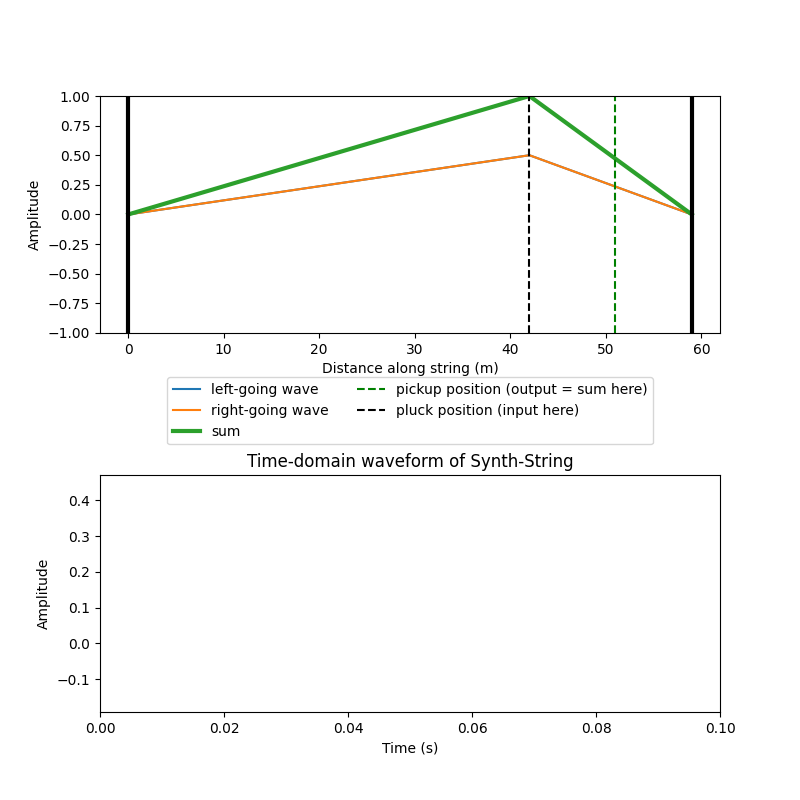

In [22]:
##### Animation to Synth some strings #######

fs = 24000 # sampling freq (Hz)
T = 1  # length of sound (s)
freq = 200 # string fundamental freq (Hz)
PL = 0.7
PU = 0.85
decay = 0.99

tt = np.arange(0,T,1/fs)   # time range of signal
[y_out, pluck_input, xx, pluck_pos, pick_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!
L = len(xx) # number of spatial samples for string

# We're going to repeat a few things from the function here just so 
# that we understand how the waveform is being generated. After that we'll analyze it a bit more.

# This is a pre-computation for left/right strings
yl = np.zeros([L,T*fs])
yr = np.zeros([L,T*fs])

yl[:,0] = pluck_input.copy()
yr[:,0] = pluck_input.copy()

for j in np.arange(0,T*fs-1,1): # generating each sample of the temporal sound
    

    yr[1:L,j+1] = yr[0:L-1,j] # shifting the motion to the right
    yl[0:L-1,j+1] = yl[1:L,j] # shifting the motion  to the left
    
    yr[0,j+1] = -decay*yl[0,j+1] # losses
    yl[-1,j+1] = -decay*yr[-1,j+1] # losses
    


# Setup the plot environments

fig, axes = plt.subplots(2,1,figsize=(8, 8)) 
fig.subplots_adjust(hspace=0.6)
line_left, = axes[0].plot(xx,pluck_input,label='left-going wave')
line_right, = axes[0].plot(xx,pluck_input,label='right-going wave')
line_sum, = axes[0].plot(xx,pluck_input+pluck_input,label='sum',linewidth=3)
axes[0].axvline(x=xx[0],color='k',linestyle='-',linewidth=3)
axes[0].axvline(x=xx[-1],color='k',linestyle='-',linewidth=3)
axes[0].axvline(x=pick_pos,color='g',linestyle='--',label='pickup position (output = sum here)')
axes[0].axvline(x=pluck_pos,color='k',linestyle='--',label='pluck position (input here)')
axes[0].set_xlabel('Distance along string (m)')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim([-1, 1])
axes[0].legend(loc='lower center',ncol=2,bbox_to_anchor=[0.5, -0.5])


axes[1].plot([])
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Time-domain waveform of Synth-String')
axes[1].set_xlim([0, 0.1])
axes[1].set_ylim([np.min(y_out), np.max(y_out)])
line2, = axes[1].plot([],[],'g-',linewidth=1, markersize=1)


print("Listen to the synth string signal:")
IPython.display.display(Audio(y_out.T, rate=fs,normalize=True))


N_frames = int(np.round(0.1*fs)) 

def animate_string(n): 

    line_left.set_data(xx,yl[:,n])
    line_right.set_data(xx,yr[:,n])
    line_sum.set_data(xx,yl[:,n] + yr[:,n])
    line2.set_data(tt[0:n+1], y_out[0:n+1])
    
    return line_left, line_right, line_sum, line2

anim = FuncAnimation(fig, animate_string, frames=N_frames, interval=40, blit=False) # this calls the function to do the animation
plt.show()
# plt.close(fig)


# Option 1: GIF (no ffmpeg)
#anim.save("string_animation.gif", writer="pillow", fps=30)

### Let's look a little more into the synthesized string

Move the slider to see how the hyperparameters affect performance 


interactive(children=(IntSlider(value=100, description='freq', max=1000, min=100), FloatSlider(value=0.7, desc…

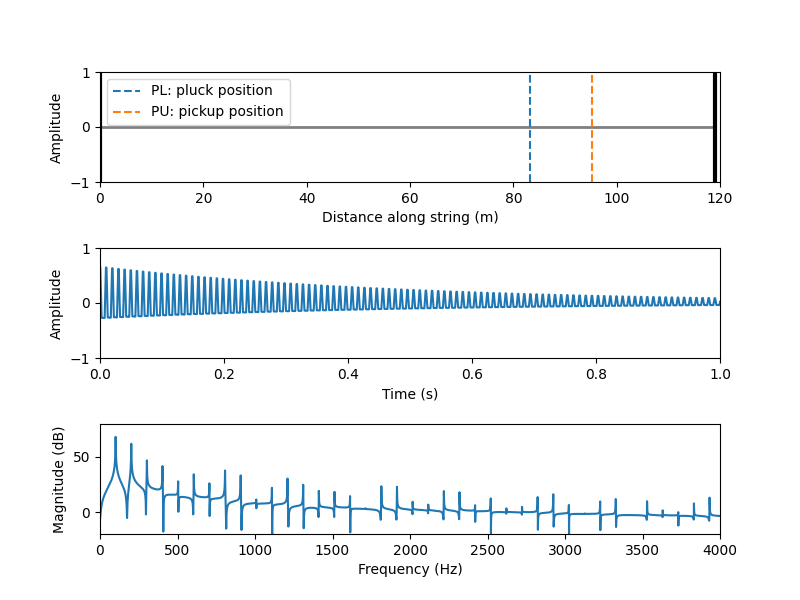

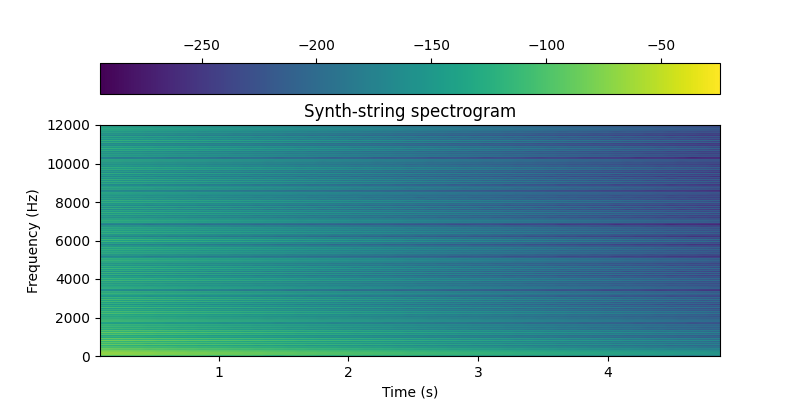

In [47]:
fs = 24000
T = 5
tt = np.arange(0,T,1/fs)

fig, axes = plt.subplots(3,1,figsize=(8, 6)) 
fig.subplots_adjust(hspace=0.6)


# axes[0].axvline(x=xx[0],color='k',linestyle='-',linewidth=3)
# axes[0].axvline(x=xx[-1],color='k',linestyle='-',linewidth=3)
stringline, = axes[0].plot([],[],color='grey',linestyle='-',linewidth=2)
linestart, = axes[0].plot([],[],color='k',linestyle='-',linewidth=3)
lineend, = axes[0].plot([],[],color='k',linestyle='-',linewidth=3)
linePL, = axes[0].plot([],[],linestyle='--',label='PL: pluck position')
linePU, = axes[0].plot([],[],linestyle='--',label='PU: pickup position')


axes[0].set_xlabel('Distance along string (m)')
axes[0].set_ylabel('Amplitude')
axes[0].set_xlim([0, 120])
axes[0].set_ylim([-1, 1])
axes[0].legend(loc='upper left')

line_wav, = axes[1].plot([],[])
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')
axes[1].set_ylim([-1, 1])
axes[1].set_xlim([0, 1])


line_fft, = axes[2].plot([],[])
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Magnitude (dB)')
axes[2].set_xlim([0, 4000])
axes[2].set_ylim([-20, 80])



def update(freq = 100, PL = 0.7, PU =0.8, decay=0.99):
    
    [y_out, pluck_input, xx, pluck_pos, pickup_pos]  = dws(sound_len=T, freq=freq, PL=PL, PU=PU, decay=decay, fs=fs) # synthesize the string!

    stringline.set_data([xx[0],xx[-1]],[0,0])
    linestart.set_data([xx[0],xx[0]],[-1,1])
    lineend.set_data([xx[-1],xx[-1]],[-1,1])
    linePU.set_data([PU*xx[-1], PU*xx[-1]],[-1,1])
    linePL.set_data([PL*xx[-1], PL*xx[-1]],[-1,1])

    
    line_wav.set_data(tt,y_out)
    
    
    print("Listen to the synth string signal:")
    IPython.display.display(Audio(y_out.T, rate=fs,normalize=True))
    
    
    # FFT
    Y = np.fft.fft(y_out)
    Y_mag_ss = np.abs(Y[0:len(y_out)//2+1])
    df = fs/len(y_out)
    freq_fft = np.arange(0,fs/2+df,df)

    line_fft.set_data(freq_fft,20*np.log10(Y_mag_ss))

    #     # ####### Computing spectrograms ######

    # # Spectrogram parameters
    nfft = 4096         # number of points for the FFT 
    noverlap = nfft//2  # Spectrogram overlap (make it 50 %)

    # # Spectrogram of the input signal
    f_sg, t_sg, Z_mag = signal.spectrogram(y_out, fs=fs,nperseg=nfft,window='hann',mode='magnitude',noverlap=noverlap)
    Z_dB = 10*np.log10(Z_mag**2) # convert the magnitude to dB
    extent = t_sg[0], t_sg[-1], f_sg[0], f_sg[-1]  # this defines the 4 corners of the "image" for the imshow function to plot spectrogram



    fig, axes = plt.subplots(figsize=(8, 4)) 
    sp = axes.imshow(Z_dB, origin='lower',aspect='auto',extent=extent, vmin=np.min(Z_dB),vmax=np.max(Z_dB))
    axes.set_xlabel('Time (s)')
    axes.set_ylabel('Frequency (Hz)')
    axes.set_xlim(t_sg[0], t_sg[-1])
    axes.set_ylim([0,fs/2])
    axes.set_title('Synth-string spectrogram')
    cb = plt.colorbar(sp,ax=[axes],location='top', pad=0.1)



print('Move the slider to see how the hyperparameters affect performance ')
interact(update, freq = (100,1000,1), PL = (0.01,0.99,0.01), PU = (0.01,0.99,0.01), decay = (0.80,0.99,0.01));


### KArplus Strong Model

https://ccrma.stanford.edu/~jos/pasp/Computational_Savings.html

120000
Input:


Output:


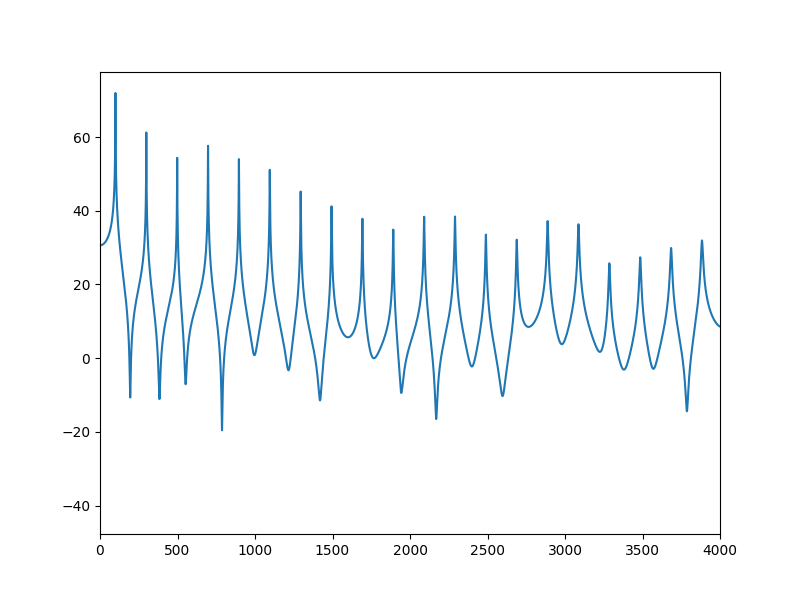

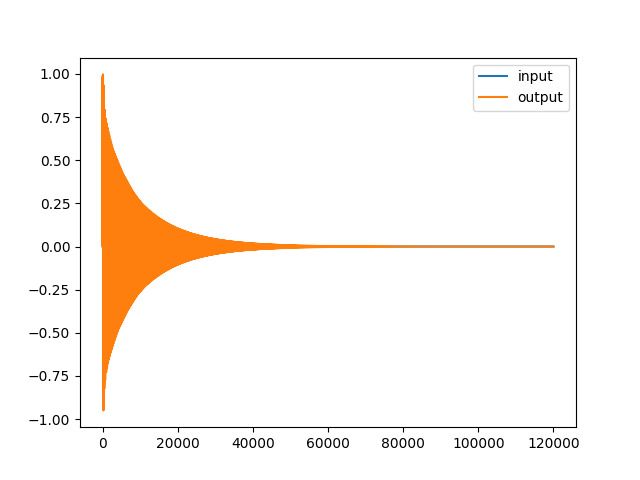

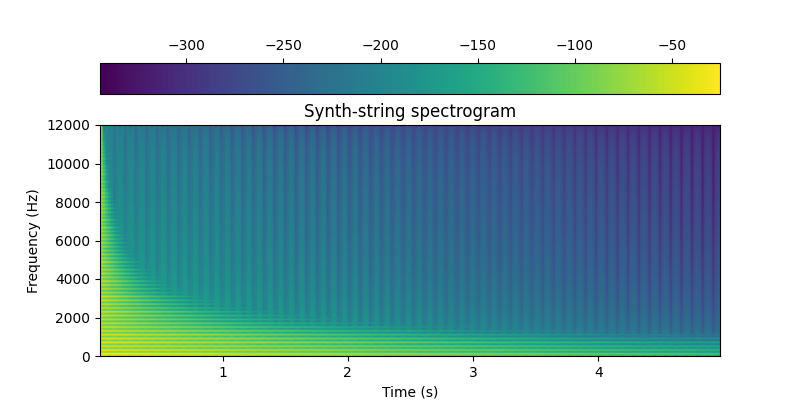

In [71]:
# Karplus strong vs. normal synthesized zound.

fs = 24000 # sampling frequency
freq = 200 # fundamental freq
N = int(np.round(fs/freq)) # number of samples for string
T = 5

x = np.zeros(T*fs);


# Need to create delay lines:
# numerator = z^-N --> this means that the b_N coefficient = 1 and all previous values are zero 
# b = signal.firwin(N+2, cutoff=3*freq, fs=fs) #https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.firwin.html
b = np.zeros(N)
b[-1] = 1 # make the last value 1 

# denominator = 1 - H(z)z^-N --> H(z) here is what can change and should be a "loop filter" - FIR

# a = np.array([1])
a = np.concatenate(( [1], np.zeros(N-1), [0.4895], [0.5] ))

# initial state of the system
zi_size = np.maximum(len(a), len(b)) - 1 
zinit = np.random.rand(zi_size) # these are the iniital values of the system (See here: http://matlab.izmiran.ru/help/toolbox/signal/basic17a.html)


[w,h] = signal.freqz(b,a, fs=fs)

fig, ax = plt.subplots(figsize=(8, 6))
# ax.plot(w,20*np.log10(np.abs(h)))

y_filt = signal.lfilter(b,a,x,zi=zinit)
y = y_filt[0]
print(len(y))

# FFT
Y_filt = np.fft.fft(y)
Y_filt_mag_ss = np.abs(Y_filt[0:len(y)//2+1])
df = fs/len(y)
freq_fft = np.arange(0,fs/2+df,df)

ax.plot(freq_fft,20*np.log10(Y_filt_mag_ss))
ax.set_xlim([0, 4000])

fig, ax = plt.subplots()
ax.plot(x, label = 'input')
ax.plot(y, label='output')
ax.legend()

print("Input:")
IPython.display.display(Audio(x.T, rate=fs,normalize=False))

print("Output:")
IPython.display.display(Audio(y.T, rate=fs,normalize=False))

# # Spectrogram parameters
nfft = 1024         # number of points for the FFT 
noverlap = nfft//2  # Spectrogram overlap (make it 50 %)

# # Spectrogram of the input signal
f_sg, t_sg, Z_mag = signal.spectrogram(y, fs=fs,nperseg=nfft,window='hann',mode='magnitude',noverlap=noverlap)
Z_dB = 10*np.log10(Z_mag**2) # convert the magnitude to dB
extent = t_sg[0], t_sg[-1], f_sg[0], f_sg[-1]  # this defines the 4 corners of the "image" for the imshow function to plot spectrogram



fig, axes = plt.subplots(figsize=(8, 4)) 
sp = axes.imshow(Z_dB, origin='lower',aspect='auto',extent=extent, vmin=np.min(Z_dB),vmax=np.max(Z_dB))
axes.set_xlabel('Time (s)')
axes.set_ylabel('Frequency (Hz)')
axes.set_xlim(t_sg[0], t_sg[-1])
axes.set_ylim([0,fs/2])
axes.set_title('Synth-string spectrogram')
cb = plt.colorbar(sp,ax=[axes],location='top', pad=0.1)

# print(len(b))
# print(len(a))
# print(b)